# visualisering v_1

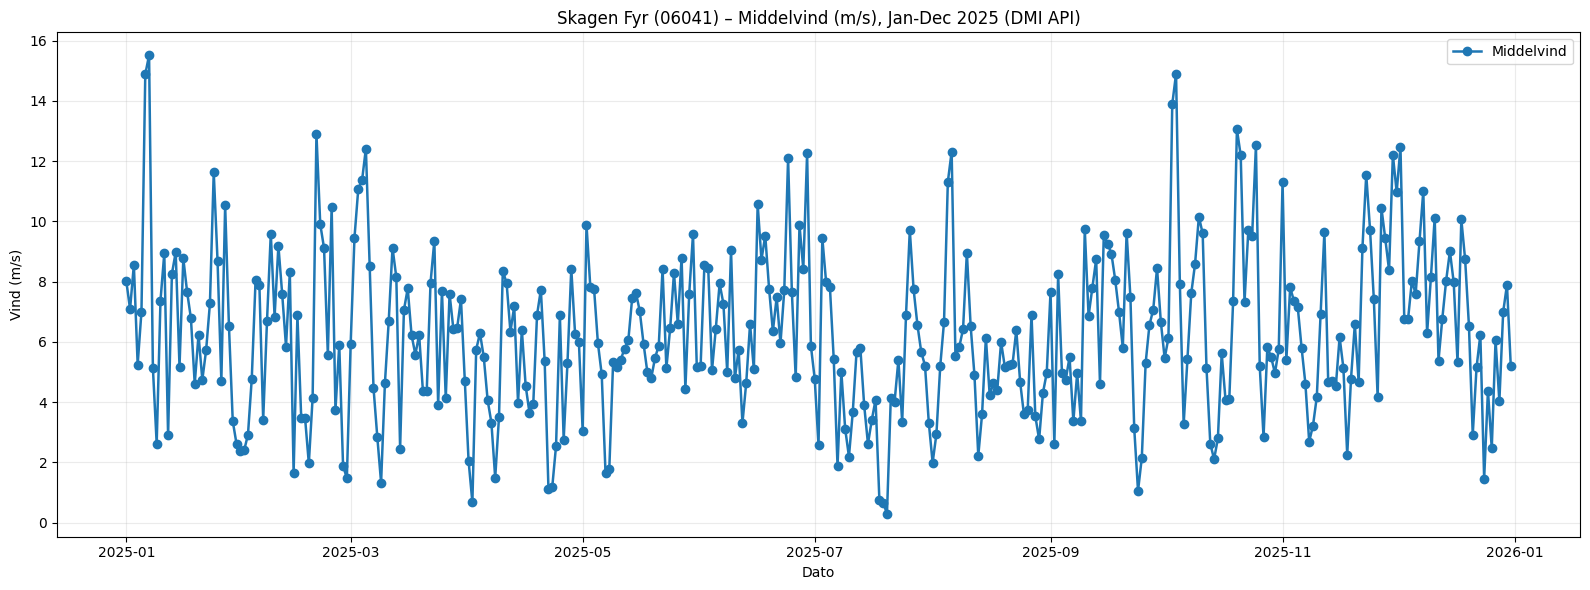

Station used: Skagen Fyr (06041)
Parameter used: wind_speed
Total days in year: 365
Days with data: 365
Laveste daglige gennemsnitsvind: 0.30 m/s (2025-07-20)
Højeste daglige gennemsnitsvind: 15.52 m/s (2025-01-07)

Daglige værdier for 2025:
--------------------------------------------
2025-01-01: 8.03 m/s
2025-01-02: 7.09 m/s
2025-01-03: 8.56 m/s
2025-01-04: 5.25 m/s
2025-01-05: 7.01 m/s
2025-01-06: 14.89 m/s
2025-01-07: 15.52 m/s
2025-01-08: 5.15 m/s
2025-01-09: 2.62 m/s
2025-01-10: 7.37 m/s
2025-01-11: 8.95 m/s
2025-01-12: 2.90 m/s
2025-01-13: 8.26 m/s
2025-01-14: 8.98 m/s
2025-01-15: 5.18 m/s
2025-01-16: 8.77 m/s
2025-01-17: 7.66 m/s
2025-01-18: 6.78 m/s
2025-01-19: 4.61 m/s
2025-01-20: 6.24 m/s
2025-01-21: 4.74 m/s
2025-01-22: 5.73 m/s
2025-01-23: 7.28 m/s
2025-01-24: 11.64 m/s
2025-01-25: 8.69 m/s
2025-01-26: 4.71 m/s
2025-01-27: 10.54 m/s
2025-01-28: 6.52 m/s
2025-01-29: 3.37 m/s
2025-01-30: 2.61 m/s
2025-01-31: 2.39 m/s
2025-02-01: 2.40 m/s
2025-02-02: 2.93 m/s
2025-02-03: 4.79

,Middelvind
2025-01-01 00:00:00+00:00,8.030556
2025-01-02 00:00:00+00:00,7.092308
2025-01-03 00:00:00+00:00,8.559441
2025-01-04 00:00:00+00:00,5.250000
2025-01-05 00:00:00+00:00,7.011189
...,...
2025-12-27 00:00:00+00:00,6.053472
2025-12-28 00:00:00+00:00,4.029861
2025-12-29 00:00:00+00:00,6.994444
2025-12-30 00:00:00+00:00,7.898611


In [66]:
import os

from datetime import date, timedelta



import requests

import pandas as pd

import matplotlib.pyplot as plt



API_BASE = "https://opendataapi.dmi.dk/v2/metObs"

API_KEY = os.getenv("DMI_API_KEY", "")

STATION_NAME = os.getenv("DMI_STATION_NAME", "Skagen")

STATION_ID = os.getenv("DMI_STATION_ID", "")  # Optional override

PARAMETER_ID = "wind_speed"  # Middelvind

YEAR = 2025





def dmi_get(path: str, params: dict) -> dict:

    url = f"{API_BASE}{path}"

    request_params = dict(params)

    if API_KEY:

        request_params["api-key"] = API_KEY



    response = requests.get(url, params=request_params, timeout=45)

    response.raise_for_status()

    return response.json()





# Resolve station for Skagen (or use explicit STATION_ID override)

if STATION_ID:

    station_payload = dmi_get(

        "/collections/station/items",

        {

            "stationId": STATION_ID,

            "limit": 1,

        },

    )

    station_features = station_payload.get("features", [])

    if not station_features:

        raise RuntimeError(f"No station found for DMI_STATION_ID={STATION_ID}")

    station_props = station_features[0].get("properties", {})

    station_name = station_props.get("name", STATION_ID)

else:

    station_payload = dmi_get(

        "/collections/station/items",

        {

            "limit": 3000,

        },

    )

    station_features = station_payload.get("features", [])



    skagen_candidates = []

    for feature in station_features:

        props = feature.get("properties", {})

        name = str(props.get("name", ""))

        if "skagen" in name.lower():

            station_id_candidate = props.get("stationId")

            if station_id_candidate:

                skagen_candidates.append((str(station_id_candidate), name))



    if not skagen_candidates:

        raise RuntimeError(

            "Could not auto-find a Skagen station. Set DMI_STATION_ID manually and run again."

        )



    skagen_candidates.sort(key=lambda x: x[0])

    STATION_ID, station_name = skagen_candidates[0]





# Fetch wind speed observations month-by-month to avoid truncation

rows = []

for month in range(1, 13):

    month_start = date(YEAR, month, 1)

    if month == 12:

        next_month_start = date(YEAR + 1, 1, 1)

    else:

        next_month_start = date(YEAR, month + 1, 1)



    start_iso = f"{month_start.isoformat()}T00:00:00Z"

    end_iso = f"{(next_month_start - timedelta(days=1)).isoformat()}T23:59:59Z"

    date_range = f"{start_iso}/{end_iso}"



    obs_payload = dmi_get(

        "/collections/observation/items",

        {

            "stationId": STATION_ID,

            "parameterId": PARAMETER_ID,

            "datetime": date_range,

            "limit": 300000,

        },

    )



    for feature in obs_payload.get("features", []):

        props = feature.get("properties", {})

        observed = props.get("observed")

        value = props.get("value")

        if observed is None or value is None:

            continue

        rows.append((pd.to_datetime(observed, utc=True), float(value)))



if not rows:

    raise RuntimeError(

        f"No wind_speed data found for station {STATION_ID} in {YEAR}. "

        "Try another station by setting DMI_STATION_ID."

    )



wind_speed_series = pd.Series(

    [value for _, value in rows],

    index=[timestamp for timestamp, _ in rows],

).sort_index()



# Aggregate to daily mean values for all 365 days

start = pd.Timestamp(f"{YEAR}-01-01", tz="UTC")

end = pd.Timestamp(f"{YEAR}-12-31", tz="UTC")

all_days = pd.date_range(start, end, freq="D")



df = pd.DataFrame(index=all_days)

df["Middelvind"] = wind_speed_series.resample("D").mean()



valid_wind = df["Middelvind"].dropna()

if valid_wind.empty:

    raise RuntimeError("No daily wind values available for min/max calculation.")



min_wind_ms = valid_wind.min()

max_wind_ms = valid_wind.max()

min_wind_day = valid_wind.idxmin().strftime("%Y-%m-%d")

max_wind_day = valid_wind.idxmax().strftime("%Y-%m-%d")



# Plot Middelvind

plt.figure(figsize=(16, 6))

plt.plot(df.index, df["Middelvind"], marker="o", linewidth=1.8, label="Middelvind")

plt.title(f"{station_name} ({STATION_ID}) – Middelvind (m/s), Jan-Dec {YEAR} (DMI API)")

plt.ylabel("Vind (m/s)")

plt.xlabel("Dato")

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.show()



print(f"Station used: {station_name} ({STATION_ID})")

print(f"Parameter used: {PARAMETER_ID}")

print(f"Total days in year: {len(df)}")

print(f"Days with data: {df['Middelvind'].notna().sum()}")

print(f"Laveste daglige gennemsnitsvind: {min_wind_ms:.2f} m/s ({min_wind_day})")

print(f"Højeste daglige gennemsnitsvind: {max_wind_ms:.2f} m/s ({max_wind_day})")

print("\nDaglige værdier for 2025:")

print("-" * 44)



for day, value in df["Middelvind"].items():

    day_str = day.strftime("%Y-%m-%d")

    if pd.isna(value):

        print(f"{day_str}: no data")

    else:

        print(f"{day_str}: {value:.2f} m/s")



df

In [67]:
# Daily kWh production from daily wind speed using your power table (kW)



import pandas as pd



if "df" not in globals() or "Middelvind" not in df.columns:

    raise RuntimeError("Run cell 1 first, so df with daily wind data is available.")



power_curve_kw = {

    0: 0.0,

    1: 0.0,

    2: 0.0,

    3: 1.2,

    4: 7.2,

    5: 14.5,

    6: 24.7,

    7: 37.9,

    8: 58.7,

    9: 74.8,

    10: 85.1,

    11: 90.2,

    12: 94.7,

    13: 99.0,

    14: 99.0,

    15: 99.0,

    16: 99.0,

}



def power_from_wind(v_ms: float) -> float:

    if pd.isna(v_ms):

        return 0.0



    v = max(0.0, min(16.0, float(v_ms)))

    lower = int(v)

    upper = min(lower + 1, 16)



    p_low = power_curve_kw[lower]

    p_high = power_curve_kw[upper]



    if upper == lower:

        return p_low



    share = v - lower

    return p_low + (p_high - p_low) * share



df_kwh = df.copy()

df_kwh["Effekt_kW"] = df_kwh["Middelvind"].apply(power_from_wind)

df_kwh["kWh_pr_dag"] = df_kwh["Effekt_kW"] * 24



total_kwh_year = df_kwh["kWh_pr_dag"].sum()



print("Daglig produktion i 2025 (baseret på vind og effektkurve):")

print("-" * 74)

for day, row in df_kwh.iterrows():

    day_str = day.strftime("%Y-%m-%d")

    if pd.isna(row["Middelvind"]):

        print(f"{day_str}: no data -> 0.00 kWh")

    else:

        print(

            f"{day_str}: {row['Middelvind']:.2f} m/s -> {row['Effekt_kW']:.2f} kW -> {row['kWh_pr_dag']:.2f} kWh"

        )



print("-" * 74)

print(f"Samlet kWh produceret i 2025: {total_kwh_year:,.2f} kWh")



df_kwh[["Middelvind", "Effekt_kW", "kWh_pr_dag"]]

Daglig produktion i 2025 (baseret på vind og effektkurve):
--------------------------------------------------------------------------
2025-01-01: 8.03 m/s -> 59.19 kW -> 1420.61 kWh
2025-01-02: 7.09 m/s -> 39.82 kW -> 955.68 kWh
2025-01-03: 8.56 m/s -> 67.71 kW -> 1624.97 kWh
2025-01-04: 5.25 m/s -> 17.05 kW -> 409.20 kWh
2025-01-05: 7.01 m/s -> 38.13 kW -> 915.19 kWh
2025-01-06: 14.89 m/s -> 99.00 kW -> 2376.00 kWh
2025-01-07: 15.52 m/s -> 99.00 kW -> 2376.00 kWh
2025-01-08: 5.15 m/s -> 16.02 kW -> 384.38 kWh
2025-01-09: 2.62 m/s -> 0.75 kW -> 17.90 kWh
2025-01-10: 7.37 m/s -> 45.69 kW -> 1096.45 kWh
2025-01-11: 8.95 m/s -> 73.95 kW -> 1774.81 kWh
2025-01-12: 2.90 m/s -> 1.08 kW -> 25.80 kWh
2025-01-13: 8.26 m/s -> 62.88 kW -> 1509.16 kWh
2025-01-14: 8.98 m/s -> 74.48 kW -> 1787.63 kWh
2025-01-15: 5.18 m/s -> 16.36 kW -> 392.68 kWh
2025-01-16: 8.77 m/s -> 71.17 kW -> 1707.99 kWh
2025-01-17: 7.66 m/s -> 51.72 kW -> 1241.36 kWh
2025-01-18: 6.78 m/s -> 35.05 kW -> 841.21 kWh
2025-01-19: 

,Middelvind,Effekt_kW,kWh_pr_dag
2025-01-01 00:00:00+00:00,8.030556,59.191944,1420.606667
2025-01-02 00:00:00+00:00,7.092308,39.820000,955.680000
2025-01-03 00:00:00+00:00,8.559441,67.706993,1624.967832
2025-01-04 00:00:00+00:00,5.250000,17.050000,409.200000
2025-01-05 00:00:00+00:00,7.011189,38.132727,915.185455
...,...,...,...
2025-12-27 00:00:00+00:00,6.053472,25.405833,609.740000
2025-12-28 00:00:00+00:00,4.029861,7.417986,178.031667
2025-12-29 00:00:00+00:00,6.994444,37.826667,907.840000
2025-12-30 00:00:00+00:00,7.898611,56.591111,1358.186667


In [68]:
# Laso: 100 houses with random household types and daily electricity usage
import random

city_name = "Laso"
house_count = 100
days_in_year = 365

# Daily consumption assumptions (kWh/day)
single_kwh = 5.3
couple_kwh = 6.0
family_kwh_min = 12.3
family_kwh_max = 13.7

household_types = ["Single", "Par", "Familie"]

houses = []
for house_id in range(1, house_count + 1):
    household_type = random.choice(household_types)

    if household_type == "Single":
        daily_kwh = single_kwh
    elif household_type == "Par":
        daily_kwh = couple_kwh
    else:
        daily_kwh = round(random.uniform(family_kwh_min, family_kwh_max), 1)

    houses.append(
        {
            "Hus": house_id,
            "Type": household_type,
            "Dagligt_forbrug_kWh": daily_kwh,
        }
    )

daily_city_kwh = sum(house["Dagligt_forbrug_kWh"] for house in houses)
yearly_city_kwh = daily_city_kwh * days_in_year

print(f"By: {city_name}")
print(f"Antal huse: {house_count}")
print("\nFordeling og dagligt forbrug pr. hus:")
print("-" * 64)
for house in houses:
    print(
        f"Hus {house['Hus']:>3}: {house['Type']:<8} -> {house['Dagligt_forbrug_kWh']:.1f} kWh/dag"
    )

print("-" * 64)
print(f"Samlet dagligt forbrug i byen: {daily_city_kwh:.1f} kWh/dag")
print(f"Samlet forbrug på {days_in_year} dage: {yearly_city_kwh:,.1f} kWh")

# Regelmotor: kun vind + batteri + import ved mangel + eksport ved batteri-overløb.
if "df_kwh" not in globals() or "kWh_pr_dag" not in df_kwh.columns:
    print("\nKør celle 3 først for at beregne vindmøllens daglige produktion (kWh_pr_dag).")
else:
    battery_capacity_kwh = 2000.0
    battery_level_kwh = 0.0
    print(f"Starter batteriniveau 01/01/{YEAR}: {battery_level_kwh:.1f} kWh")
    print(f"Maks batterikapacitet: {battery_capacity_kwh:.1f} kWh")

    total_stored_kwh = 0.0
    total_direct_used_kwh = 0.0
    total_from_battery_kwh = 0.0
    total_import_kwh = 0.0
    total_export_kwh = 0.0
    import_details = []

    print("\nDaglig balance: produktion, forbrug, batteri, import og eksport")
    print("-" * 128)

    for day, row in df_kwh.iterrows():
        production_kwh = float(row["kWh_pr_dag"] if not pd.isna(row["kWh_pr_dag"]) else 0.0)
        demand_kwh = float(daily_city_kwh)

        direct_used_kwh = min(production_kwh, demand_kwh)
        remaining_need_kwh = demand_kwh - direct_used_kwh

        from_battery_kwh = min(battery_level_kwh, remaining_need_kwh)
        battery_level_kwh -= from_battery_kwh
        remaining_need_kwh -= from_battery_kwh

        import_kwh = max(0.0, remaining_need_kwh)
        remaining_need_kwh -= import_kwh

        surplus_kwh = max(0.0, production_kwh - demand_kwh)
        battery_level_kwh += surplus_kwh

        export_kwh = 0.0
        if battery_level_kwh > battery_capacity_kwh:
            export_kwh = battery_level_kwh - battery_capacity_kwh
            battery_level_kwh = battery_capacity_kwh

        total_stored_kwh += surplus_kwh
        total_direct_used_kwh += direct_used_kwh
        total_from_battery_kwh += from_battery_kwh
        total_import_kwh += import_kwh
        total_export_kwh += export_kwh

        day_str = day.strftime('%Y-%m-%d')
        print(
            f"{day_str}: prod {production_kwh:.2f} | forbrug {demand_kwh:.2f} | "
            f"direkte {direct_used_kwh:.2f} | fra batteri {from_battery_kwh:.2f} | "
            f"import {import_kwh:.2f} | til batteri +{surplus_kwh:.2f} | "
            f"eksport {export_kwh:.2f} | batteri nu {battery_level_kwh:.2f} kWh"
        )

        if import_kwh > 0:
            import_details.append((day_str, import_kwh))

    print("-" * 128)
    print(f"Samlet lagret i batteri i året: {total_stored_kwh:,.2f} kWh")
    print(f"Samlet direkte brugt strøm i byen: {total_direct_used_kwh:,.2f} kWh")
    print(f"Samlet trukket fra batteri: {total_from_battery_kwh:,.2f} kWh")
    print(f"Samlet import fra fastlandet: {total_import_kwh:,.2f} kWh")
    print(f"Samlet eksport til fastlandet: {total_export_kwh:,.2f} kWh")
    print(f"Ubrugt strøm ved årets slutning i batteriet: {battery_level_kwh:,.2f} kWh")

    if import_details:
        print("\nDage med import fra fastlandet:")
        print("-" * 64)
        for day_str, missing_kwh in import_details:
            print(f"{day_str}: importer {missing_kwh:.2f} kWh")
    else:
        print("\nIngen dage med import fra fastlandet.")

By: Laso
Antal huse: 100

Fordeling og dagligt forbrug pr. hus:
----------------------------------------------------------------
Hus   1: Par      -> 6.0 kWh/dag
Hus   2: Single   -> 5.3 kWh/dag
Hus   3: Par      -> 6.0 kWh/dag
Hus   4: Single   -> 5.3 kWh/dag
Hus   5: Familie  -> 12.8 kWh/dag
Hus   6: Familie  -> 13.3 kWh/dag
Hus   7: Familie  -> 12.8 kWh/dag
Hus   8: Par      -> 6.0 kWh/dag
Hus   9: Familie  -> 12.4 kWh/dag
Hus  10: Par      -> 6.0 kWh/dag
Hus  11: Familie  -> 12.9 kWh/dag
Hus  12: Familie  -> 12.3 kWh/dag
Hus  13: Familie  -> 12.6 kWh/dag
Hus  14: Familie  -> 13.5 kWh/dag
Hus  15: Familie  -> 12.3 kWh/dag
Hus  16: Familie  -> 12.8 kWh/dag
Hus  17: Familie  -> 12.8 kWh/dag
Hus  18: Par      -> 6.0 kWh/dag
Hus  19: Par      -> 6.0 kWh/dag
Hus  20: Familie  -> 12.8 kWh/dag
Hus  21: Familie  -> 13.7 kWh/dag
Hus  22: Par      -> 6.0 kWh/dag
Hus  23: Familie  -> 12.7 kWh/dag
Hus  24: Single   -> 5.3 kWh/dag
Hus  25: Single   -> 5.3 kWh/dag
Hus  26: Par      -> 6.0 kWh/dag

In [69]:
# Batteri
if "df_kwh" not in globals() or "kWh_pr_dag" not in df_kwh.columns:
    raise RuntimeError("Kør celle 3 først, så df_kwh med vindmølleproduktion findes.")

if "daily_city_kwh" not in globals():
    raise RuntimeError("Kør celle 4 først, så byens daglige forbrug (daily_city_kwh) findes.")

battery_capacity_kwh = 2000.0
battery_level_kwh = 0.0
max_battery_kwh = battery_level_kwh

total_production_kwh = 0.0
total_demand_kwh = 0.0
total_to_battery_kwh = 0.0
total_from_battery_kwh = 0.0
total_import_kwh = 0.0
total_export_kwh = 0.0

print("Batteri")
print(f"Starter batteriniveau 01/01/{YEAR}: {battery_level_kwh:.1f} kWh")
print(f"Maks batterikapacitet: {battery_capacity_kwh:.1f} kWh")
print("Daglig balance mellem vindmølle, forbrug, batteri, import og eksport")
print("-" * 144)

for day, row in df_kwh.iterrows():
    production_kwh = float(row["kWh_pr_dag"] if not pd.isna(row["kWh_pr_dag"]) else 0.0)
    demand_kwh = float(daily_city_kwh)

    total_production_kwh += production_kwh
    total_demand_kwh += demand_kwh

    direct_to_city_kwh = min(production_kwh, demand_kwh)
    remaining_need_kwh = demand_kwh - direct_to_city_kwh

    from_battery_kwh = min(battery_level_kwh, remaining_need_kwh)
    battery_level_kwh -= from_battery_kwh
    remaining_need_kwh -= from_battery_kwh

    import_kwh = max(0.0, remaining_need_kwh)
    remaining_need_kwh -= import_kwh

    to_battery_kwh = max(0.0, production_kwh - demand_kwh)
    battery_level_kwh += to_battery_kwh

    export_kwh = 0.0
    if battery_level_kwh > battery_capacity_kwh:
        export_kwh = battery_level_kwh - battery_capacity_kwh
        battery_level_kwh = battery_capacity_kwh

    total_to_battery_kwh += to_battery_kwh
    total_from_battery_kwh += from_battery_kwh
    total_import_kwh += import_kwh
    total_export_kwh += export_kwh
    max_battery_kwh = max(max_battery_kwh, battery_level_kwh)

    day_str = day.strftime('%Y-%m-%d')
    print(
        f"{day_str} | prod: {production_kwh:8.2f} | forbrug: {demand_kwh:8.2f} | "
        f"direkte: {direct_to_city_kwh:8.2f} | +bat: {to_battery_kwh:8.2f} | "
        f"-bat: {from_battery_kwh:8.2f} | import: {import_kwh:8.2f} | "
        f"eksport: {export_kwh:8.2f} | bat_niveau: {battery_level_kwh:10.2f}"
    )

print("-" * 144)
print(f"Samlet vindmølleproduktion: {total_production_kwh:,.2f} kWh")
print(f"Samlet byforbrug:          {total_demand_kwh:,.2f} kWh")
print(f"Samlet lagret i batteri:   {total_to_battery_kwh:,.2f} kWh")
print(f"Samlet trukket fra batteri:{total_from_battery_kwh:,.2f} kWh")
print(f"Samlet import fra fastland:{total_import_kwh:,.2f} kWh")
print(f"Samlet eksport til fastland:{total_export_kwh:,.2f} kWh")
print(f"Batteri ved årets slut:    {battery_level_kwh:,.2f} kWh")
print(f"Maks batteriniveau i året: {max_battery_kwh:,.2f} kWh")

Batteri
Starter batteriniveau 01/01/2025: 0.0 kWh
Maks batterikapacitet: 2000.0 kWh
Daglig balance mellem vindmølle, forbrug, batteri, import og eksport
------------------------------------------------------------------------------------------------------------------------------------------------
2025-01-01 | prod:  1420.61 | forbrug:   842.30 | direkte:   842.30 | +bat:   578.31 | -bat:     0.00 | import:     0.00 | eksport:     0.00 | bat_niveau:     578.31
2025-01-02 | prod:   955.68 | forbrug:   842.30 | direkte:   842.30 | +bat:   113.38 | -bat:     0.00 | import:     0.00 | eksport:     0.00 | bat_niveau:     691.69
2025-01-03 | prod:  1624.97 | forbrug:   842.30 | direkte:   842.30 | +bat:   782.67 | -bat:     0.00 | import:     0.00 | eksport:     0.00 | bat_niveau:    1474.35
2025-01-04 | prod:   409.20 | forbrug:   842.30 | direkte:   409.20 | +bat:     0.00 | -bat:   433.10 | import:     0.00 | eksport:     0.00 | bat_niveau:    1041.25
2025-01-05 | prod:   915.19 | forbrug:

In [70]:
# transformer
# Agent-flow:
# vindmølle -> transformerstation -> by (Laso)
# overskud fra transformer -> batteri (maks 2000 kWh), resten eksporteres til fastlandet
# underskud i transformer -> anmodning til batteri -> import fra fastlandet -> by

if "df_kwh" not in globals() or "kWh_pr_dag" not in df_kwh.columns:
    raise RuntimeError("Kør celle 3 først, så vindmøllens daglige produktion (df_kwh['kWh_pr_dag']) findes.")

if "daily_city_kwh" not in globals():
    raise RuntimeError("Kør celle 4 først, så byens daglige forbrug (daily_city_kwh) findes.")

city_name = "Laso"
battery_capacity_kwh = 2000.0
battery_level_kwh = 0.0

total_wind_to_transformer = 0.0
total_transformer_to_city = 0.0
total_transformer_to_battery = 0.0
total_battery_to_transformer = 0.0
total_import_kwh = 0.0
total_export_kwh = 0.0

print("transformer")
print(f"Starter batteriniveau 01/01/{YEAR}: {battery_level_kwh:.1f} kWh")
print(f"Maks batterikapacitet: {battery_capacity_kwh:.1f} kWh")
print("Flow: vindmølle -> transformer -> by (+ batteri, import og eksport via transformer)")
print("-" * 156)

for day, row in df_kwh.iterrows():
    wind_production_kwh = float(row["kWh_pr_dag"] if not pd.isna(row["kWh_pr_dag"]) else 0.0)
    transformer_energy_kwh = wind_production_kwh
    city_request_kwh = float(daily_city_kwh)

    direct_to_city_kwh = min(transformer_energy_kwh, city_request_kwh)
    transformer_energy_kwh -= direct_to_city_kwh
    remaining_city_need_kwh = city_request_kwh - direct_to_city_kwh

    battery_to_transformer_kwh = min(battery_level_kwh, remaining_city_need_kwh)
    battery_level_kwh -= battery_to_transformer_kwh
    remaining_city_need_kwh -= battery_to_transformer_kwh

    import_kwh = max(0.0, remaining_city_need_kwh)
    remaining_city_need_kwh -= import_kwh

    transformer_to_city_from_battery_kwh = battery_to_transformer_kwh

    transformer_to_battery_kwh = max(0.0, transformer_energy_kwh)
    battery_level_kwh += transformer_to_battery_kwh

    export_kwh = 0.0
    if battery_level_kwh > battery_capacity_kwh:
        export_kwh = battery_level_kwh - battery_capacity_kwh
        battery_level_kwh = battery_capacity_kwh

    total_wind_to_transformer += wind_production_kwh
    total_transformer_to_city += (direct_to_city_kwh + transformer_to_city_from_battery_kwh + import_kwh)
    total_transformer_to_battery += transformer_to_battery_kwh
    total_battery_to_transformer += battery_to_transformer_kwh
    total_import_kwh += import_kwh
    total_export_kwh += export_kwh

    day_str = day.strftime('%Y-%m-%d')
    print(
        f"{day_str} | Vind->Trafo: {wind_production_kwh:8.2f} | "
        f"By anmoder: {city_request_kwh:8.2f} | "
        f"Trafo->By: {(direct_to_city_kwh + transformer_to_city_from_battery_kwh + import_kwh):8.2f} | "
        f"Trafo->Batteri: {transformer_to_battery_kwh:8.2f} | "
        f"Batteri->Trafo: {battery_to_transformer_kwh:8.2f} | "
        f"Import: {import_kwh:8.2f} | Eksport: {export_kwh:8.2f} | "
        f"Batteriniveau: {battery_level_kwh:9.2f} kWh"
    )

print("-" * 156)
print(f"Samlet vindmølle -> transformer: {total_wind_to_transformer:,.2f} kWh")
print(f"Samlet transformer -> by ({city_name}): {total_transformer_to_city:,.2f} kWh")
print(f"Samlet transformer -> batteri (lagret): {total_transformer_to_battery:,.2f} kWh")
print(f"Samlet batteri -> transformer: {total_battery_to_transformer:,.2f} kWh")
print(f"Samlet import fra fastlandet: {total_import_kwh:,.2f} kWh")
print(f"Samlet eksport til fastlandet: {total_export_kwh:,.2f} kWh")
print(f"Batteri ved årets slutning: {battery_level_kwh:,.2f} kWh")

transformer
Starter batteriniveau 01/01/2025: 0.0 kWh
Maks batterikapacitet: 2000.0 kWh
Flow: vindmølle -> transformer -> by (+ batteri, import og eksport via transformer)
------------------------------------------------------------------------------------------------------------------------------------------------------------
2025-01-01 | Vind->Trafo:  1420.61 | By anmoder:   842.30 | Trafo->By:   842.30 | Trafo->Batteri:   578.31 | Batteri->Trafo:     0.00 | Import:     0.00 | Eksport:     0.00 | Batteriniveau:    578.31 kWh
2025-01-02 | Vind->Trafo:   955.68 | By anmoder:   842.30 | Trafo->By:   842.30 | Trafo->Batteri:   113.38 | Batteri->Trafo:     0.00 | Import:     0.00 | Eksport:     0.00 | Batteriniveau:    691.69 kWh
2025-01-03 | Vind->Trafo:  1624.97 | By anmoder:   842.30 | Trafo->By:   842.30 | Trafo->Batteri:   782.67 | Batteri->Trafo:     0.00 | Import:     0.00 | Eksport:     0.00 | Batteriniveau:   1474.35 kWh
2025-01-04 | Vind->Trafo:   409.20 | By anmoder:   842.30 |

Starter batteriniveau 01/01/2025: 0.0 kWh
Maks batterikapacitet: 2000.0 kWh
10 tilfældige dage valgt:
- 2025-03-21
- 2025-05-13
- 2025-08-03
- 2025-08-09
- 2025-08-16
- 2025-08-27
- 2025-09-24
- 2025-09-30
- 2025-10-12
- 2025-10-19


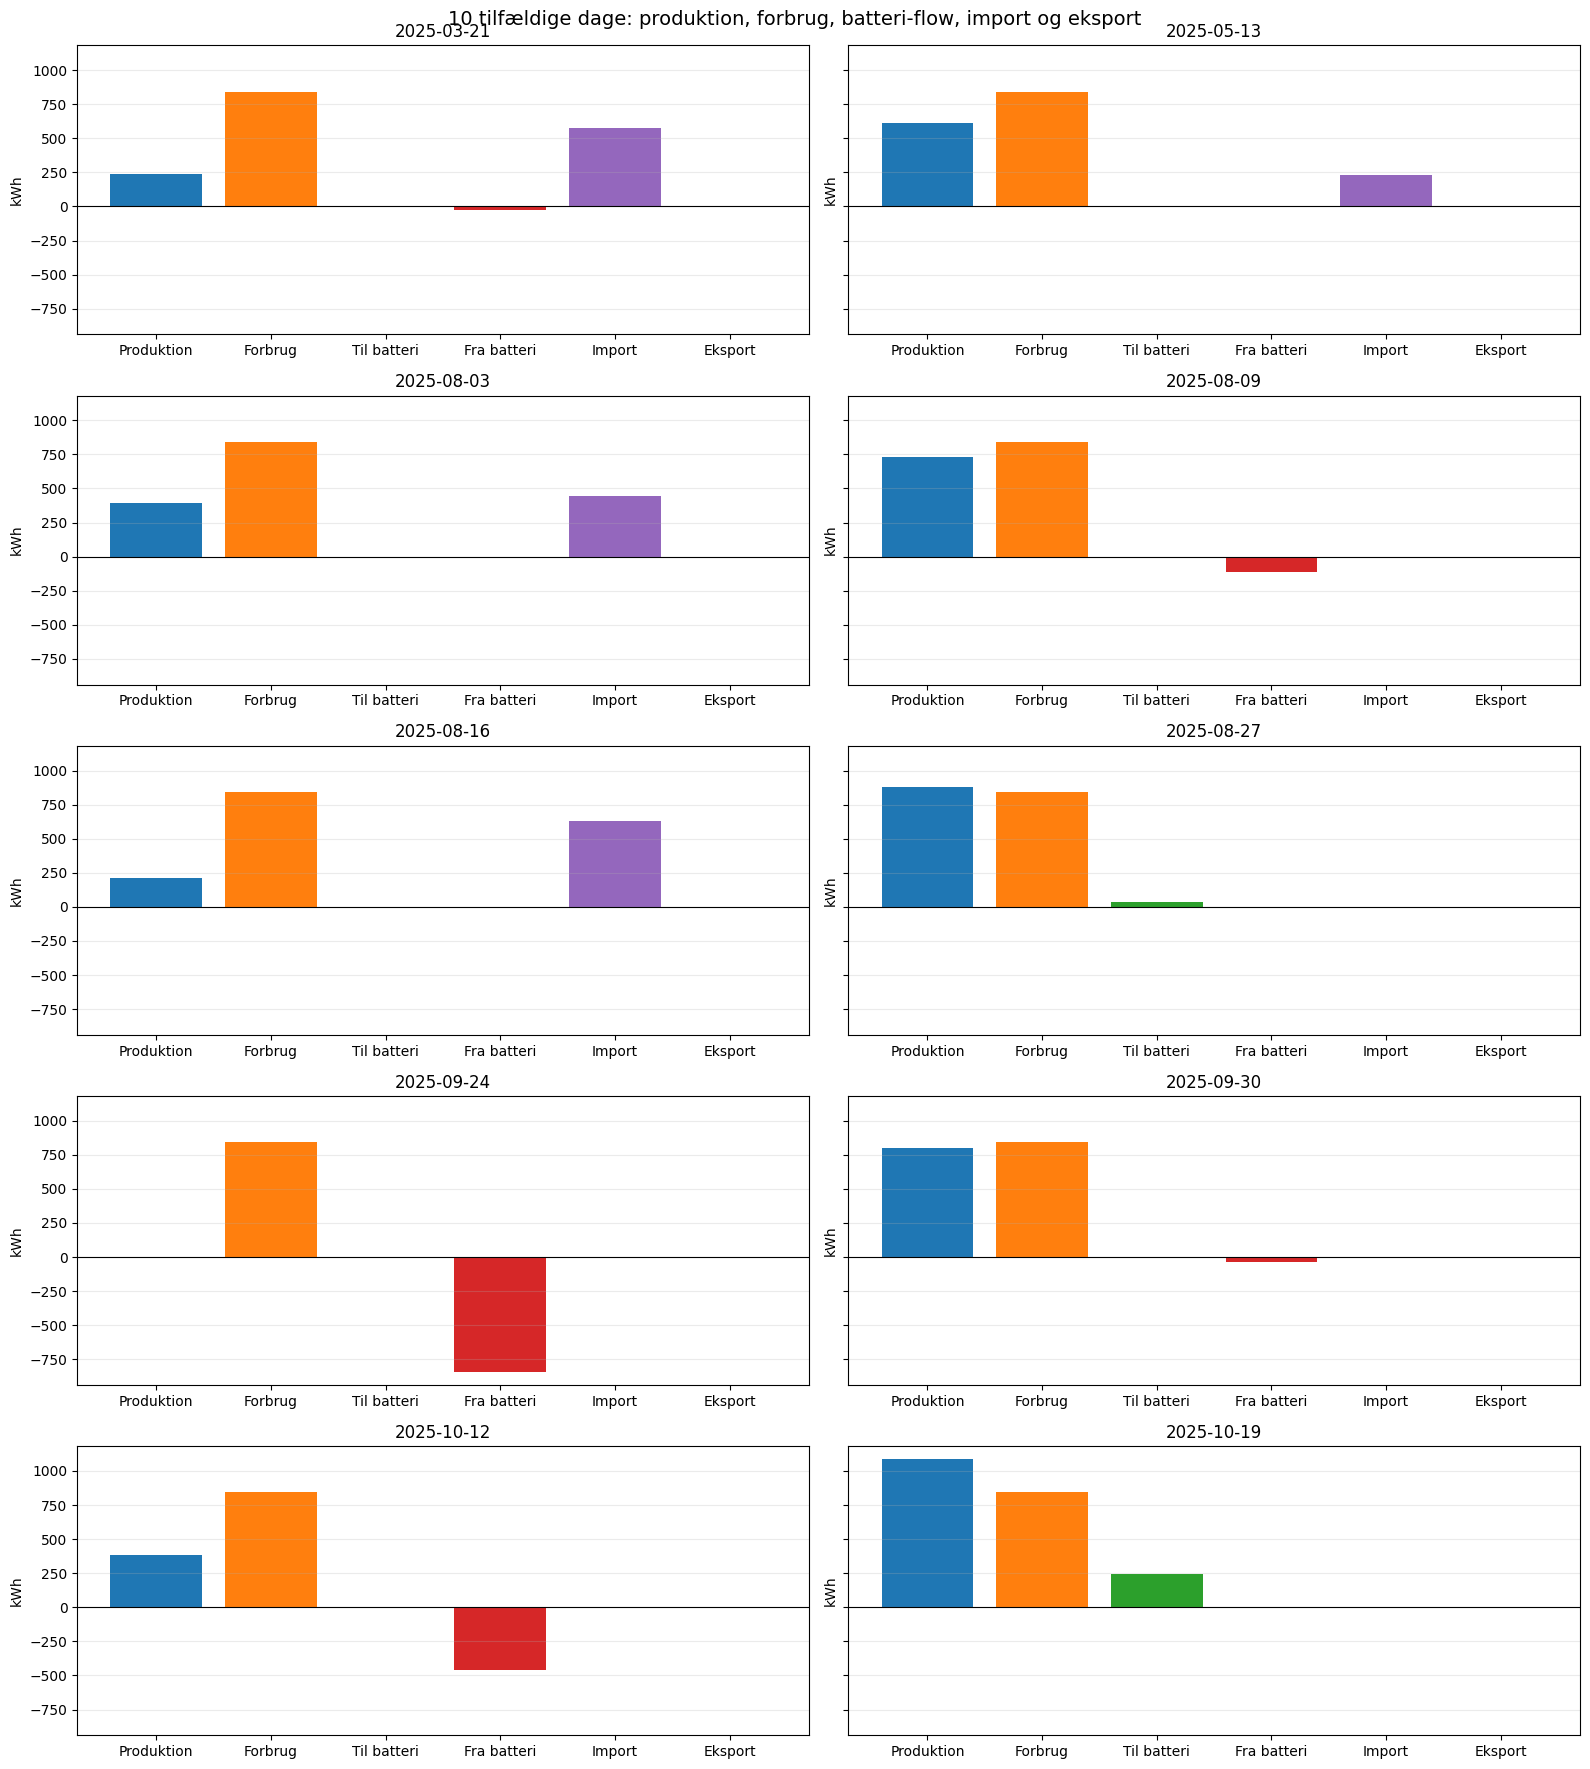

In [73]:
# 10 tilfældige dage: produktion, forbrug, batteri-flow, import og eksport
import matplotlib.pyplot as plt

if "df_kwh" not in globals() or "kWh_pr_dag" not in df_kwh.columns:
    raise RuntimeError("Kør celle 2 først (df_kwh mangler).")

if "daily_city_kwh" not in globals():
    raise RuntimeError("Kør celle 4 først (daily_city_kwh mangler).")

battery_capacity_kwh_local = 2000.0
battery_level_kwh_local = 0.0
day_rows = []
print(f"Starter batteriniveau 01/01/{YEAR}: {battery_level_kwh_local:.1f} kWh")
print(f"Maks batterikapacitet: {battery_capacity_kwh_local:.1f} kWh")

for day, row in df_kwh.iterrows():
    production_kwh = float(row["kWh_pr_dag"] if not pd.isna(row["kWh_pr_dag"]) else 0.0)
    demand_kwh = float(daily_city_kwh)

    direct_to_city_kwh = min(production_kwh, demand_kwh)
    remaining_need_kwh = demand_kwh - direct_to_city_kwh

    from_battery_kwh = min(battery_level_kwh_local, remaining_need_kwh)
    battery_level_kwh_local -= from_battery_kwh
    remaining_need_kwh -= from_battery_kwh

    import_kwh = max(0.0, remaining_need_kwh)
    remaining_need_kwh -= import_kwh

    to_battery_kwh = max(0.0, production_kwh - demand_kwh)
    battery_level_kwh_local += to_battery_kwh

    export_kwh = 0.0
    if battery_level_kwh_local > battery_capacity_kwh_local:
        export_kwh = battery_level_kwh_local - battery_capacity_kwh_local
        battery_level_kwh_local = battery_capacity_kwh_local

    day_rows.append(
        {
            "date": day,
            "production_kwh": production_kwh,
            "demand_kwh": demand_kwh,
            "to_battery_kwh": to_battery_kwh,
            "from_battery_kwh": from_battery_kwh,
            "import_kwh": import_kwh,
            "export_kwh": export_kwh,
            "battery_level_kwh": battery_level_kwh_local,
        }
    )

flow_df = pd.DataFrame(day_rows).set_index("date")

n_days = min(10, len(flow_df))
sample_df = flow_df.sample(n=n_days).sort_index()

print("10 tilfældige dage valgt:")
for day in sample_df.index:
    print("-", day.strftime("%Y-%m-%d"))

fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharey=True)
axes = axes.flatten()

for i, (day, r) in enumerate(sample_df.iterrows()):
    ax = axes[i]
    labels = ["Produktion", "Forbrug", "Til batteri", "Fra batteri", "Import", "Eksport"]
    values = [
        r["production_kwh"],
        r["demand_kwh"],
        r["to_battery_kwh"],
        -r["from_battery_kwh"],
        r["import_kwh"],
        r["export_kwh"],
    ]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    ax.bar(labels, values, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(day.strftime("%Y-%m-%d"))
    ax.set_ylabel("kWh")
    ax.grid(axis="y", alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("10 tilfældige dage: produktion, forbrug, batteri-flow, import og eksport", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Beregn nødvendigt startniveau i batteriet (uendelig kapacitet, ingen eksport)
if "df_kwh" not in globals() or "kWh_pr_dag" not in df_kwh.columns:
    raise RuntimeError("Kør celle 2 først (df_kwh mangler).")

if "daily_city_kwh" not in globals():
    raise RuntimeError("Kør celle 3 først (daily_city_kwh mangler).")

start_battery_kwh = 0.0
daily_production = df_kwh["kWh_pr_dag"].fillna(0.0).astype(float).tolist()
daily_demand = float(daily_city_kwh)
total_production_year = float(sum(daily_production))
total_demand_year = float(daily_demand * len(daily_production))

net_daily = [p - daily_demand for p in daily_production]
cum = 0.0
min_cum = 0.0
for value in net_daily:
    cum += value
    min_cum = min(min_cum, cum)
required_initial_kwh = max(0.0, -min_cum)

def simulate_shortage_days(initial_level_kwh: float):
    battery_level = initial_level_kwh
    shortage_days_count = 0
    total_unmet_kwh = 0.0

    for produced_kwh in daily_production:
        direct_used = min(produced_kwh, daily_demand)
        remaining_need = daily_demand - direct_used

        from_battery = min(battery_level, remaining_need)
        battery_level -= from_battery
        remaining_need -= from_battery

        surplus = max(0.0, produced_kwh - daily_demand)
        battery_level += surplus

        unmet = max(0.0, remaining_need)
        if unmet > 0:
            shortage_days_count += 1
            total_unmet_kwh += unmet

    return shortage_days_count, total_unmet_kwh, battery_level

shortage_days_start0, unmet_start0, end_level_start0 = simulate_shortage_days(start_battery_kwh)
shortage_days_required, unmet_required, end_level_required = simulate_shortage_days(required_initial_kwh)

print(f"Startniveau {start_battery_kwh:.0f} kWh -> {shortage_days_start0} mangeldage, {unmet_start0:.2f} kWh udækket")
print(f"Årlig produktion: {total_production_year:,.2f} kWh")
print(f"Årligt forbrug:   {total_demand_year:,.2f} kWh")
print("-" * 72)
print(f"Mindste nødvendige startniveau for 0 mangeldage: {required_initial_kwh:,.2f} kWh")
print(f"Tjek ved dette niveau -> {shortage_days_required} mangeldage, {unmet_required:.2f} kWh udækket")
print(f"Batteriniveau ved årets slut (ved minimum): {end_level_required:,.2f} kWh")

Startniveau 0 kWh -> 38 mangeldage, 16530.32 kWh udækket
Årlig produktion: 303,986.58 kWh
Årligt forbrug:   298,168.50 kWh
------------------------------------------------------------------------
Mindste nødvendige startniveau for 0 mangeldage: 16,530.32 kWh
Tjek ved dette niveau -> 1 mangeldage, 0.00 kWh udækket
Batteriniveau ved årets slut (ved minimum): 22,348.39 kWh
